# 04 - Advanced Analysis

RFM segmentation, cohort retention analysis, and customer clustering.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

DATA_PATH = Path("../data/processed/online_retail_cleaned.csv")
df = pd.read_csv(DATA_PATH, parse_dates=["InvoiceDate"])
df_sales = df[df["OrderStatus"] == "normal"].copy()
df_sales.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Year,Month,DayOfWeek,DayName,Hour,Date,Sales,OrderStatus
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,2009,12,1,Tuesday,7,2009-12-01,83.4,normal
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,2009,12,1,Tuesday,7,2009-12-01,81.0,normal
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,2009,12,1,Tuesday,7,2009-12-01,81.0,normal
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,2009,12,1,Tuesday,7,2009-12-01,100.8,normal
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,2009,12,1,Tuesday,7,2009-12-01,30.0,normal


## 1. RFM Segmentation

In [3]:
reference_date = df_sales["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df_sales.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("Sales", "sum")
).reset_index()

rfm["R_Score"] = pd.qcut(rfm["Recency"], 5, labels=[5, 4, 3, 2, 1])
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5])
rfm["M_Score"] = pd.qcut(rfm["Monetary"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5])

rfm["RFM_Segment"] = rfm["R_Score"].astype(str) + rfm["F_Score"].astype(str) + rfm["M_Score"].astype(str)
rfm["RFM_Score"] = rfm[["R_Score", "F_Score", "M_Score"]].astype(int).sum(axis=1)

rfm.head(10)

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment,RFM_Score
0,12346,326,12,77556.46,2,5,5,255,12
1,12347,2,8,4921.53,5,4,5,545,14
2,12348,75,5,2019.40,3,4,4,344,11
3,12349,19,4,4428.69,5,3,5,535,13
4,12350,310,1,334.40,2,1,2,212,5
5,12351,375,1,300.93,2,1,2,212,5
6,12352,36,10,2849.84,4,5,4,454,13
7,12353,204,2,406.76,2,2,2,222,6
8,12354,232,1,1079.40,2,1,3,213,6
9,12355,214,2,947.61,2,2,3,223,7


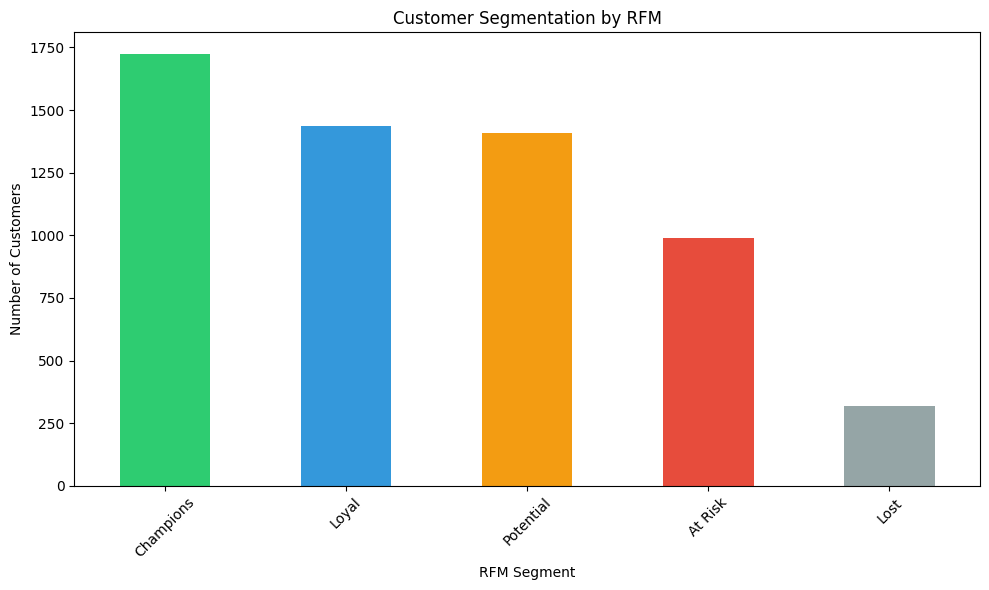

In [4]:
def assign_segment(row):
    score = row["RFM_Score"]
    if score >= 12:
        return "Champions"
    elif score >= 9:
        return "Loyal"
    elif score >= 6:
        return "Potential"
    elif score >= 4:
        return "At Risk"
    else:
        return "Lost"

rfm["Segment"] = rfm.apply(assign_segment, axis=1)
segment_counts = rfm["Segment"].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
segment_counts.plot(kind="bar", ax=ax, color=["#2ecc71", "#3498db", "#f39c12", "#e74c3c", "#95a5a6"])
ax.set_xlabel("RFM Segment")
ax.set_ylabel("Number of Customers")
ax.set_title("Customer Segmentation by RFM")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("../reports/figures/rfm_segments.png", dpi=150, bbox_inches="tight")
plt.show()

**Insight:** Champions are high-value customers. At Risk and Lost need re-engagement campaigns.

## 2. Cohort Retention Analysis

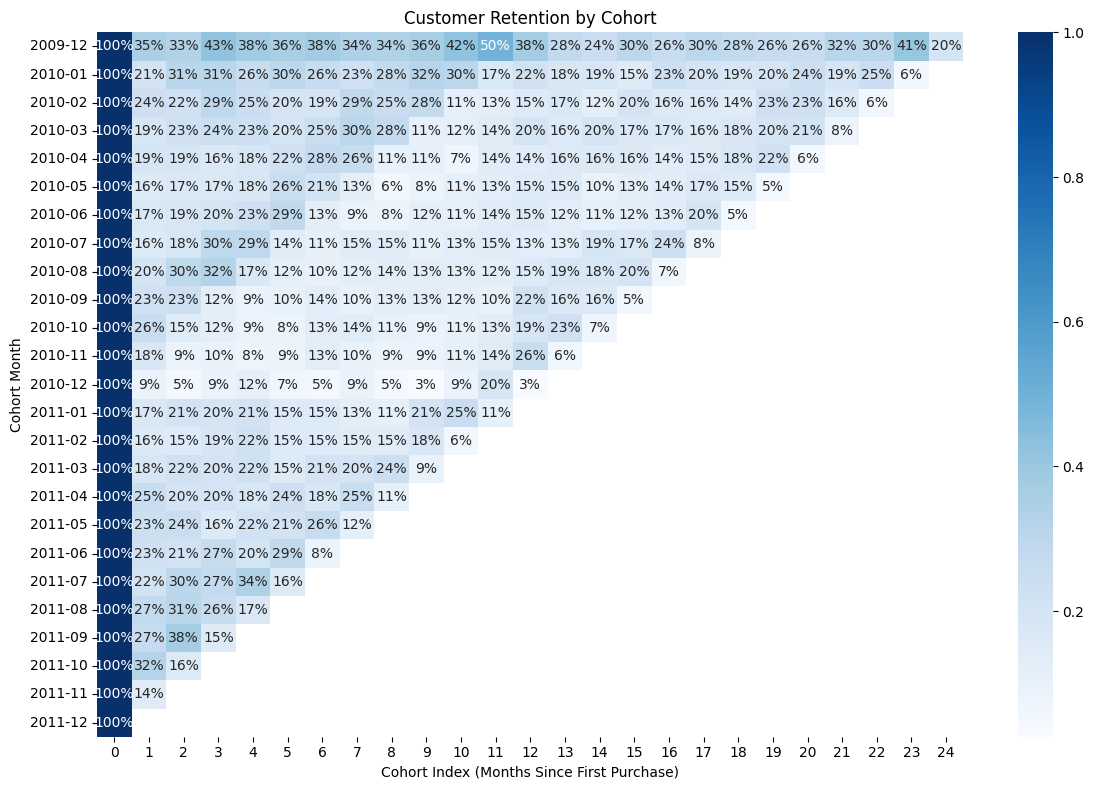

In [5]:
df_sales["InvoiceMonth"] = df_sales["InvoiceDate"].dt.to_period("M")
cohort = df_sales.groupby("CustomerID")["InvoiceMonth"].min().reset_index()
cohort.columns = ["CustomerID", "CohortMonth"]
df_sales = df_sales.merge(cohort, on="CustomerID")

# Compute cohort index as numeric month difference (robust across pandas versions)
df_sales["CohortIndex"] = (
    (df_sales["InvoiceMonth"].dt.year - df_sales["CohortMonth"].dt.year) * 12
    + (df_sales["InvoiceMonth"].dt.month - df_sales["CohortMonth"].dt.month)
).astype("int64")

cohort_data = df_sales.groupby(["CohortMonth", "CohortIndex"])["CustomerID"].nunique().reset_index()
cohort_pivot = cohort_data.pivot(index="CohortMonth", columns="CohortIndex", values="CustomerID")
cohort_size = cohort_pivot.iloc[:, 0]
retention = cohort_pivot.divide(cohort_size, axis=0)

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(retention, annot=True, fmt=".0%", cmap="Blues", ax=ax)
ax.set_xlabel("Cohort Index (Months Since First Purchase)")
ax.set_ylabel("Cohort Month")
ax.set_title("Customer Retention by Cohort")
plt.tight_layout()
plt.savefig("../reports/figures/cohort_retention.png", dpi=150, bbox_inches="tight")
plt.show()

**Insight:** Retention heatmap shows how well each cohort retains customers over time. Early months indicate onboarding effectiveness.

## 3. Customer Clustering

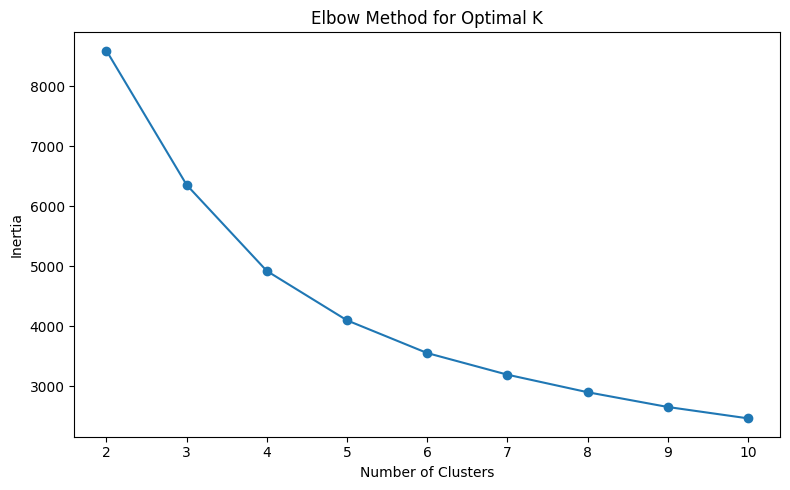

In [6]:
rfm_log = rfm[["Recency", "Frequency", "Monetary"]].copy()
rfm_log["Recency"] = np.log1p(rfm_log["Recency"])
rfm_log["Frequency"] = np.log1p(rfm_log["Frequency"])
rfm_log["Monetary"] = np.log1p(rfm_log["Monetary"])

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

inertias = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(2, 11), inertias, marker="o")
ax.set_xlabel("Number of Clusters")
ax.set_ylabel("Inertia")
ax.set_title("Elbow Method for Optimal K")
plt.tight_layout()
plt.savefig("../reports/figures/elbow_plot.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

cluster_summary = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()
cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,394.946275,1.377598,317.081501
1,28.304800,3.053600,857.491434
2,27.711538,19.275920,10731.162991
3,230.072653,5.058259,1948.503933


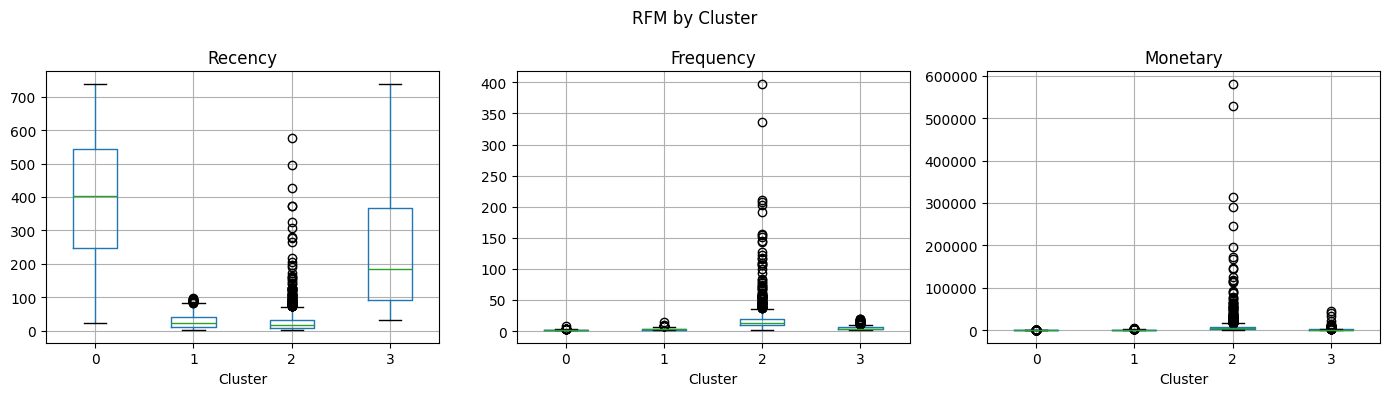

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, col in enumerate(["Recency", "Frequency", "Monetary"]):
    rfm.boxplot(column=col, by="Cluster", ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel("Cluster")
plt.suptitle("RFM by Cluster")
plt.tight_layout()
plt.savefig("../reports/figures/cluster_rfm.png", dpi=150, bbox_inches="tight")
plt.show()

**Insight:** Clusters reveal distinct customer groups. Use cluster profiles for targeted marketing and product recommendations.